# setup and imports

In [1]:
import pickle
import csv
import glob
import fnmatch
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.optimize import curve_fit
from matplotlib.collections import PolyCollection
from matplotlib.colors import to_rgba

from utils import *
from plotting import *

plt.style.use('./Figures/paper.mplstyle')

In [2]:
root = "/home/thomas/Desktop/ALLDATA"
histologyroot="/home/thomas/Desktop/HISTOLOGY"

In [3]:
lesioned_rats = ['RatF30', 'RatF31', 'RatM30', 'RatF40', 'RatF41', 'RatM41', 'RatM42',
            'RatF50', 'RatF51', 'RatF52', 'RatM50', 'RatM51', 'RatM52']

rat_markers = {}
palette = create_kiwi_green_palette(num_shades=len(lesioned_rats))

l = 0
for index, animal in enumerate(lesioned_rats):
    if fnmatch.fnmatch(animal, 'Rat*'):
        rat_markers[animal]=[palette[l], 'o']
        l += 1
    elif fnmatch.fnmatch(animal, 'Rat00*'):
        rat_markers[animal]=[(0.0, 0.0, 0.0), "$\u2426$",]
    else:
        print("error, this is not a rat you got here")

effort_sensitivity_0, effort_sensitivity_t, effort_sensitivity_u, power = pickle.load(open('picklejar/effort_sensitivity_fit.p', 'rb'))
alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u = pickle.load(open("picklejar/ModelsFitsAllRats.p", "rb"))

conds = ['60', '90', '120', '20', '10', '2', 'rev10', 'rev20']
alpha_0 = {animal: np.median([alpha_0[animal][cond] for cond in conds]) for animal in lesioned_rats}
alpha_t = {animal: np.median([alpha_t[animal][cond] for cond in conds]) for animal in lesioned_rats}
alpha_u = {animal: np.median([alpha_u[animal][cond] for cond in conds]) for animal in lesioned_rats}
gamma_0 = {animal: np.median([gamma_0[animal][cond] for cond in conds]) for animal in lesioned_rats}
gamma_t = {animal: np.median([gamma_t[animal][cond] for cond in conds]) for animal in lesioned_rats}
gamma_u = {animal: np.median([gamma_u[animal][cond] for cond in conds]) for animal in lesioned_rats}
mu_0 = {animal: np.median([mu_0[animal][cond] for cond in conds]) for animal in lesioned_rats}
mu_t = {animal: np.median([mu_t[animal][cond] for cond in conds]) for animal in lesioned_rats}
mu_u = {animal: np.median([mu_u[animal][cond] for cond in conds]) for animal in lesioned_rats}
sigma_0 = {animal: np.median([sigma_0[animal][cond] for cond in conds]) for animal in lesioned_rats}
sigma_t = {animal: np.median([sigma_t[animal][cond] for cond in conds]) for animal in lesioned_rats}
sigma_u = {animal: np.median([sigma_u[animal][cond] for cond in conds]) for animal in lesioned_rats}

vars = [effort_sensitivity_0, effort_sensitivity_t, effort_sensitivity_u, power, alpha_0, alpha_t, alpha_u, gamma_0, gamma_t, gamma_u, mu_0, mu_t, mu_u, sigma_0, sigma_t, sigma_u]
names = ['effort_sensitivity_0', 'effort_sensitivity_t', 'effort_sensitivity_u', 'beta', 'alpha_0', 'alpha_t', 'alpha_u', 'gamma_0', 'gamma_t', 'gamma_u', 'mu_0', 'mu_t', 'mu_u', 'sigma_0', 'sigma_t', 'sigma_u']


In [4]:
# manual y_limits, y_ticks and y_labels for the plots

lims = {'alpha_0': [0, 1, 2, 3],
        'alpha_t': [-0.1, 0, .1, .2, .3, .4, .5],
        'alpha_u': [-0.4, -0.2, 0, 0.2],
        'gamma_0': [0, 0.5, 1, 1.5, 2],
        'gamma_t': [-0.2, -.1, 0, 0.1],
        'gamma_u': [-.3, -.2, -0.1, 0],
        'mu_0': [.5, 1, 1.5, 2, 2.5],
        'mu_t': [0, 0.05, .1, .15, .2, ],
        'mu_u': [-.1, 0.0, .1, .2],
        'sigma_0': [0, .05, .1, .15, .2, .25],
        'sigma_t': [-.05, -.025, 0, .025, 0.05],
        'sigma_u': [-.03, 0, .03, .06, .09, .12],
        'effort_sensitivity_0': [0, 20, 40, 60],
        'effort_sensitivity_t': [0, 5, 10, 15, 20],
        'effort_sensitivity_u': [-4, -2, 0, 2, 4, 6],
        'beta': [0, 1, 2, 3, 4]}

labels = {'alpha_0': r'$\alpha_0$', 'alpha_t': r"$\alpha_t$", 'alpha_u': r"$\alpha_u$",
          'gamma_0': r'$\gamma_0$', 'gamma_t': r"$\gamma_t$", 'gamma_u': r"$\gamma_u$",
          'mu_0': r'$\mu_0$', 'mu_t': r"$\mu_t$", 'mu_u': r"$\mu_u$",
          'sigma_0': r'$\sigma_0$', 'sigma_t': r"$\sigma_t$", 'sigma_u': r"$\sigma_u$",
          'effort_sensitivity_0': r"$\varsigma_0$", 'effort_sensitivity_t': r"$\varsigma_t$", 'effort_sensitivity_u': r"$\varsigma_u$",
            'beta': r"$\beta$"}


In [5]:

def lesion_profile(ROI, res=1, downsample=100, smooth_sigma=25, xrange=None):
    """Compute the lesion integral along the mediolateral axis."""
    if ROI.shape[0] < 3:
        return [], []

    if xrange is not None:
        x_min, x_max = xrange
    else:
        x_min, x_max = np.min(ROI[:, 0]), np.max(ROI[:, 0])

    x_samples = np.arange(x_min, x_max + res, res)
    y_integrals = []

    for x in x_samples:
        crossings = []
        for i in range(len(ROI)):
            p1 = ROI[i]
            p2 = ROI[(i + 1) % len(ROI)]

            if p1[0] == p2[0]:
                if p1[0] == x:
                    crossings.extend([p1[1], p2[1]])
            elif (p1[0] <= x <= p2[0]) or (p2[0] <= x <= p1[0]):
                t = (x - p1[0]) / (p2[0] - p1[0])
                y = p1[1] + t * (p2[1] - p1[1])
                crossings.append(y)

        crossings = sorted(crossings)

        total_y = 0
        for j in range(0, len(crossings) - 1, 2):
            total_y += crossings[j+1] - crossings[j]

        y_integrals.append(total_y)

    x_samples = np.array(x_samples)
    y_integrals = np.array(y_integrals)

    if smooth_sigma > 0:
        y_integrals = gaussian_filter1d(y_integrals, sigma=smooth_sigma)

    x_new = np.linspace(x_samples[0], x_samples[-1], num=downsample)
    y_new = np.interp(x_new, x_samples, y_integrals)

    return x_new, y_new


def lesion_profile2(ROI_lesion, ROI_striatum, res=1, downsample=100, smooth_sigma=25, yrange=None):
    """Compute lesion profile along the dorsoventral axis (Y), giving lesion start/stop ratios relative to striatum."""
    if ROI_lesion.shape[0] < 3:
        return [], [], [], []
    if ROI_striatum is None or ROI_striatum.shape[0] < 3:
        return [], [], [], []

    if yrange is not None:
        y_min, y_max = yrange
    else:
        y_min = np.min(ROI_striatum[:, 1])
        y_max = np.max(ROI_striatum[:, 1])
    y_samples = np.arange(y_min, y_max + res, res)

    lesion_x_starts = []
    lesion_x_ends = []
    striatum_x_starts = []
    striatum_x_ends = []


    lesion_start_ratio = []
    lesion_end_ratio = []

    for y in y_samples:
        lesion_crossings = []
        for i in range(len(ROI_lesion)):
            p1 = ROI_lesion[i]
            p2 = ROI_lesion[(i + 1) % len(ROI_lesion)]

            if p1[1] == p2[1]:
                if p1[1] == y:
                    lesion_crossings.extend([p1[0], p2[0]])
            elif (p1[1] <= y <= p2[1]) or (p2[1] <= y <= p1[1]):
                t = (y - p1[1]) / (p2[1] - p1[1])
                x = p1[0] + t * (p2[0] - p1[0])
                lesion_crossings.append(x)

        striatum_crossings = []
        for i in range(len(ROI_striatum)):
            p1 = ROI_striatum[i]
            p2 = ROI_striatum[(i + 1) % len(ROI_striatum)]

            if p1[1] == p2[1]:
                if p1[1] == y:
                    striatum_crossings.extend([p1[0], p2[0]])
            elif (p1[1] <= y <= p2[1]) or (p2[1] <= y <= p1[1]):
                t = (y - p1[1]) / (p2[1] - p1[1])
                x = p1[0] + t * (p2[0] - p1[0])
                striatum_crossings.append(x)

        if len(lesion_crossings) >= 2 and len(striatum_crossings) >= 2:

            lesion_crossings = sorted(lesion_crossings)
            striatum_crossings = sorted(striatum_crossings)

            lesion_start = lesion_crossings[0]
            lesion_end = lesion_crossings[-1]

            str_start = striatum_crossings[0]
            str_end = striatum_crossings[-1]
            w = str_end - str_start

            if lesion_start < str_start:
                lesion_start = str_start
                # print("lesion_start < str_start")
            if lesion_start > str_end:
                lesion_start = str_end

            if lesion_end > str_end:
                lesion_end = str_end
                # print("lesion_end > str_end")
            if lesion_end < str_start:
                lesion_end = str_start
                # print("lesion_end > str_start")

            diff_start = lesion_start - str_start
            diff_end = str_end - lesion_end

            ratio_start = diff_start / w
            ratio_end = 1 - (diff_end / w)

            if w > 0 and not (ratio_end == 0 and ratio_start == 0):
                # print(f"{y}, ss:{int(str_start)}, ls:{int(lesion_start)}, ::: le:{int(lesion_end)}, se:{int(str_end)}, ::: w: {w:.2f}, start: {ratio_start:.2f}, end: {ratio_end:.2f} ::: diff_start: {diff_start:.2f}, diff_end: {diff_end:.2f}")
                lesion_start_ratio.append(ratio_start)
                lesion_end_ratio.append(ratio_end)
            else:
                # print("w is 0")
                lesion_start_ratio.append(np.nan)
                lesion_end_ratio.append(np.nan)
        
        else:

            lesion_start_ratio.append(np.nan)
            lesion_end_ratio.append(np.nan)
              

    return y_samples, lesion_start_ratio, lesion_end_ratio


def _lesion_bar(ax, x_new, y_new, base_y=0, height=100, color='red', secondary_color='k', forced_max=None):
    """Plot a horizontal bar with opacity varying with y_new values."""
    x_new = np.array(x_new)
    y_new = np.array(y_new)

    if forced_max is not None:
        y_norm = (y_new - np.min(y_new)) / (forced_max - np.min(y_new) + 1e-8)
    else:
        y_norm = (y_new - np.min(y_new)) / (np.max(y_new) - np.min(y_new) + 1e-8)
    y_max = np.max(y_new)
    x_at_max = x_new[np.argmax(y_new)]

    for i in range(len(x_new) - 1):
        x0 = x_new[i]
        x1 = x_new[i+1]
        alpha = y_norm[i]

        rect = Polygon(
            [[x0, base_y],
             [x1, base_y],
             [x1, base_y + height],
             [x0, base_y + height]],
            closed=True,
            facecolor=secondary_color if x0 == x_at_max else color,
            edgecolor=None,
            alpha=min(1, alpha)
        )
        ax.add_patch(rect)


# rasterized
def lesion_bar(ax, x_new, y_new, base_y=0, height=100, color='red', secondary_color='k', forced_max=None):
    x_new = np.array(x_new)
    y_new = np.array(y_new)

    if forced_max is not None:
        y_norm = (y_new - np.min(y_new)) / (forced_max - np.min(y_new) + 1e-8)
    else:
        y_norm = (y_new - np.min(y_new)) / (np.max(y_new) - np.min(y_new) + 1e-8)

    y_max = np.max(y_new)
    x_at_max = x_new[np.argmax(y_new)]

    polys = []
    facecolors = []

    for i in range(len(x_new) - 1):
        x0 = x_new[i]
        x1 = x_new[i+1]
        alpha = min(1, y_norm[i])
        c = color
        # c = secondary_color if x0 <= x_at_max <= x1 else color

        polys.append([
            [x0, base_y],
            [x1, base_y],
            [x1, base_y + height],
            [x0, base_y + height]
        ])
        facecolors.append(to_rgba(c, alpha))

    collection = PolyCollection(polys, facecolors=facecolors, edgecolors='none')
    collection.set_rasterized(True) 
    ax.add_collection(collection)
    ax.plot([x_at_max, x_at_max],
        [base_y, base_y + height],
        color=(0.2, 0.2, 0.2),
        linewidth=.5,
        solid_capstyle='butt',
        zorder=10)


def plot_bicolor_polygon(polygon, facecolor='g', light_color='lightgreen', dark_color='darkgreen',
                ax=None):
    if ax is None:
        ax = plt.gca()

    y_vals = polygon[:, 1]
    top_idx = np.argmin(y_vals)
    bottom_idx = np.argmax(y_vals)

    if top_idx < bottom_idx:
        left_side = polygon[top_idx:bottom_idx + 1]
        right_side = np.vstack((polygon[bottom_idx:], polygon[:top_idx + 1]))
    else:
        left_side = np.vstack((polygon[top_idx:], polygon[:bottom_idx + 1]))
        right_side = polygon[bottom_idx:top_idx + 1]

    face = Polygon(polygon, closed=True, facecolor=facecolor, alpha=0.075)
    ax.add_patch(face)

    ax.plot(left_side[:, 0], left_side[:, 1], light_color)
    ax.plot(right_side[:, 0], right_side[:, 1], dark_color)


# explanation plot

/home/thomas/Desktop/HISTOLOGY/RatF50/slice3.czi


/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:126: RuntimeWarning: invalid value encountered in double_scalars
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:127: RuntimeWarning: invalid value encountered in double_scalars


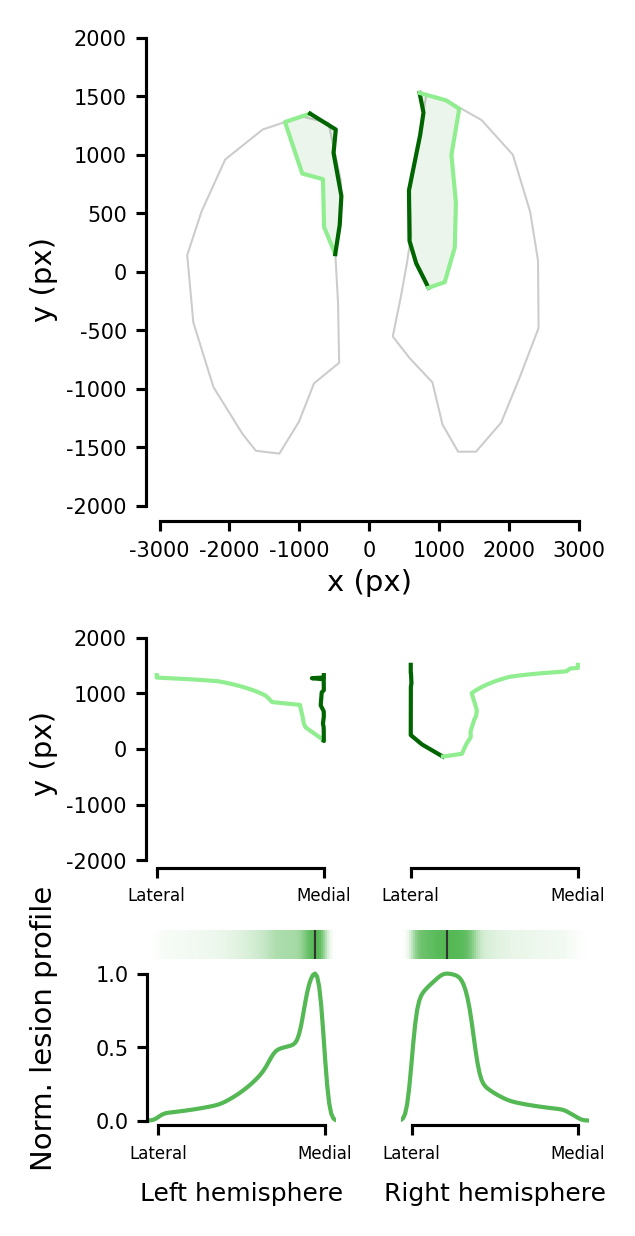

In [6]:
def explanation_plot(ax_anat=None, ax_profile_L=None, ax_profile_R=None,
                     ax_lesion_bar_L=None, ax_lesion_bar_R=None):

    if ax_anat is None or ax_profile_L is None or ax_profile_R is None or ax_lesion_bar_L is None or ax_lesion_bar_R is None:
        fig = plt.figure(figsize=(2, 4))
        gs0 = fig.add_gridspec(3, 1, height_ratios=[1, 0.5, 0.5])
        ax_anat = fig.add_subplot(gs0[0])
        middle_row = gs0[1].subgridspec(1, 2, width_ratios=[1, 1])
        ax_profile_L = fig.add_subplot(middle_row[0, 0])
        ax_profile_R = fig.add_subplot(middle_row[0, 1], sharey=ax_profile_L)

        bottom_row = gs0[2].subgridspec(1, 2, width_ratios=[1, 1])
        ax_lesion_bar_L = fig.add_subplot(bottom_row[0, 0], sharex=ax_profile_L)
        ax_lesion_bar_R = fig.add_subplot(bottom_row[0, 1], sharey=ax_lesion_bar_L, sharex=ax_profile_R)
    animal = 'RatF50'
    
    animalFolder = histologyroot + '/' + animal
    slicenumber = glob.glob(animalFolder + '/slice*')
    slicenumber = [slice.split('/')[-1] for slice in slicenumber]
    slices = [animalFolder + '/slice'  + str(''.join(filter(str.isdigit, string))) + '.czi' for string in slicenumber]
    slice = slices[0]
    print(slice)

    # left
    x = read_ROI_from_csv(slice[:-4] + '_Left_Striatum.csv')[:, 0]
    y = read_ROI_from_csv(slice[:-4] + '_Left_Striatum.csv')[:, 1]
    x = np.append(x, x[0])
    y = np.append(y, y[0])
    y = -y  # flip y axis

    offset_x = np.mean(x) + 1250
    offset_y = np.mean(y)

    ax_anat.plot(x - offset_x, y - offset_y, 'k', alpha=0.2, lw=.5)

    x_lesion = read_ROI_from_csv(slice[:-4] + '_Left_Lesion.csv')[:, 0]
    y_lesion = read_ROI_from_csv(slice[:-4] + '_Left_Lesion.csv')[:, 1]
    x_lesion = np.append(x_lesion, x_lesion[0])
    y_lesion = np.append(y_lesion, y_lesion[0])
    y_lesion = -y_lesion  # flip y axis

    polygon = np.array([x_lesion - offset_x, y_lesion - offset_y]).T
    plot_bicolor_polygon(polygon, facecolor='g', light_color='lightgreen', dark_color='darkgreen', ax=ax_anat)

    _y, start, stop = lesion_profile2(np.array([x_lesion - offset_x, y_lesion - offset_y]).T,
                            np.array([x - offset_x, y - offset_y]).T,
                            res=1, yrange=(-2150, 1850))

    ax_profile_L.plot(start, _y, 'lightgreen')
    ax_profile_L.plot(stop, _y, 'darkgreen')

    current_shape_x = np.concatenate([start, stop[::-1]])
    current_shape_y = np.concatenate([_y, _y[::-1]])
    current_shape = np.array([current_shape_x, current_shape_y]).T
    current_shape = current_shape[~np.isnan(current_shape).any(axis=1)]


    _x, _y = lesion_profile(np.array([current_shape[:, 0], current_shape[:, 1]]).T,
                            res=.001, xrange=(-.1, 1.1))
    norm_y = (_y - np.min(_y)) / (np.max(_y) - np.min(_y) + 1e-8)
    ax_lesion_bar_L.plot(_x, norm_y, color=rat_markers[animal][0])

    lesion_bar(ax_lesion_bar_L, _x, _y, base_y=1.1, height=.5, color=rat_markers[animal][0])

    



    # right
    x = read_ROI_from_csv(slice[:-4] + '_Right_Striatum.csv')[:, 0]
    y = read_ROI_from_csv(slice[:-4] + '_Right_Striatum.csv')[:, 1]
    x = np.append(x, x[0])
    y = np.append(y, y[0])
    y = -y  # flip y axis

    offset_x = np.mean(x) - 1250
    offset_y = np.mean(y)

    ax_anat.plot(x - offset_x, y - offset_y, 'k', alpha=0.2, lw=.5)

    x_lesion = read_ROI_from_csv(slice[:-4] + '_Right_Lesion.csv')[:, 0]
    y_lesion = read_ROI_from_csv(slice[:-4] + '_Right_Lesion.csv')[:, 1]
    x_lesion = np.append(x_lesion, x_lesion[0])
    y_lesion = np.append(y_lesion, y_lesion[0])
    y_lesion = -y_lesion  # flip y axis


    polygon = np.array([x_lesion - offset_x, y_lesion - offset_y]).T
    plot_bicolor_polygon(polygon, facecolor='g', light_color='darkgreen', dark_color='lightgreen', ax=ax_anat)

    _y, start, stop = lesion_profile2(np.array([x_lesion - offset_x, y_lesion - offset_y]).T,
                            np.array([x - offset_x, y - offset_y]).T,
                            res=1, yrange=(-2150, 1850))

    ax_profile_R.plot([_ for _ in start], _y, 'darkgreen')
    ax_profile_R.plot([_ for _ in stop], _y, 'lightgreen')

    current_shape_x = np.concatenate([start, stop[::-1]])
    current_shape_y = np.concatenate([_y, _y[::-1]])
    current_shape = np.array([current_shape_x, current_shape_y]).T
    current_shape = current_shape[~np.isnan(current_shape).any(axis=1)]


    _x, _y = lesion_profile(np.array([current_shape[:, 0], current_shape[:, 1]]).T,
                            res=.001, xrange=(-.1, 1.1))
    norm_y = (_y - np.min(_y)) / (np.max(_y) - np.min(_y) + 1e-8)
    ax_lesion_bar_R.plot(_x, norm_y, color=rat_markers[animal][0])
    lesion_bar(ax_lesion_bar_R, _x, _y, base_y=1.1, height=.5, color=rat_markers[animal][0])



    ax_anat.set_xlim(-3000, 3000)
    ax_anat.set_ylim(-2000, 2000)
    ax_anat.set_xlabel('x (px)')
    ax_anat.set_ylabel('y (px)')
    space_axes(ax_anat)


    ax_profile_L.set_ylim(-2000, 2000)
    ax_profile_L.set_ylabel('y (px)')
    ax_profile_L.set_xlim(0, 1)
    ax_profile_L.set_xticks([0, 1])
    ax_profile_L.set_xticklabels(['Lateral', 'Medial'], fontsize=4)
    ax_profile_L.set_yticks([-2000, -1000, 0, 1000, 2000])
    space_axes(ax_profile_L, x_ratio_left=1/15, x_ratio_right=1/15)

    ax_profile_R.set_ylim(-2000, 2000)
    ax_profile_R.spines['left'].set_visible(False)
    ax_profile_R.tick_params(left=False, labelleft=False)
    ax_profile_R.set_xlim(0, 1)
    ax_profile_R.set_xticks([0, 1])
    ax_profile_R.set_xticklabels(['Lateral', 'Medial'], fontsize=4)
    ax_profile_R.set_yticks([-2000, -1000, 0, 1000, 2000])
    space_axes(ax_profile_R, x_ratio_left=1/15, x_ratio_right=1/15)



    ax_lesion_bar_L.set_ylim(0, 1)
    ax_lesion_bar_L.set_xlim(0, 1)
    ax_lesion_bar_L.set_xticks([0, 1])
    ax_lesion_bar_L.set_xticklabels(['Lateral', 'Medial'], fontsize=4)
    ax_lesion_bar_L.set_ylabel('Norm. lesion profile', labelpad=9)
    space_axes(ax=ax_lesion_bar_L, x_ratio_left=1/15, x_ratio_right=1/15, top_y=0.3)

    ax_lesion_bar_R.set_ylim(0, 1)
    ax_lesion_bar_R.set_xlim(0, 1)
    ax_lesion_bar_R.set_xticks([0, 1])
    ax_lesion_bar_R.set_xticklabels(['Lateral', 'Medial'], fontsize=4)
    ax_lesion_bar_R.spines['left'].set_visible(False)
    ax_lesion_bar_R.tick_params(left=False, labelleft=False)
    space_axes(ax=ax_lesion_bar_R, x_ratio_left=1/15, x_ratio_right=1/15, top_y=0.3)

    ax_lesion_bar_L.text(.5, -.5, 'Left hemisphere', va='center', ha='center', fontsize=6)
    ax_lesion_bar_R.text(.5, -.5, 'Right hemisphere', va='center', ha='center', fontsize=6)


fig = plt.figure(figsize=(2, 4))
gs0 = fig.add_gridspec(3, 1, height_ratios=[1, 0.5, 0.5])
ax_anat = fig.add_subplot(gs0[0, 0])
middle_row = gs0[1].subgridspec(1, 2, width_ratios=[1, 1])
ax_profile_L = fig.add_subplot(middle_row[0, 0])
ax_profile_R = fig.add_subplot(middle_row[0, 1], sharey=ax_profile_L)

bottom_row = gs0[2].subgridspec(1, 2, width_ratios=[1, 1])
ax_lesion_bar_L = fig.add_subplot(bottom_row[0, 0], sharex=ax_profile_L)
ax_lesion_bar_R = fig.add_subplot(bottom_row[0, 1], sharey=ax_lesion_bar_L, sharex=ax_profile_R)
explanation_plot(ax_anat, ax_profile_L, ax_profile_R, ax_lesion_bar_L, ax_lesion_bar_R)

# Compute lesion extent for each slice

In [7]:
def compute_extent_lesion_all_rats():
    N = 4
    MAX = 1500
    left_centroids = {animal: {slice: {'x': 0, 'y': 0} for slice in range(0, 3)} for animal in lesioned_rats}
    right_centroids = {animal: {slice: {'x': 0, 'y': 0} for slice in range(0, 3)} for animal in lesioned_rats}
    slice_names = {animal: [] for animal in lesioned_rats}
    lesions_by_side = []

    for i, animal in enumerate(lesioned_rats):

        animalFolder = histologyroot + '/' + animal
        slicenumber = glob.glob(animalFolder + '/slice*')
        slicenumber = [slice.split('/')[-1] for slice in slicenumber]
        slices = set([animalFolder + '/slice' + str(''.join(filter(str.isdigit, string))) + '.czi' for string in slicenumber]) 
        slices = sorted(slices, key=lambda x: int(x.split('/')[-1].split('slice')[1].split('.')[0]))

        for j, slice in enumerate(slices):
            print(animal, slice)
            slice_name = slice.split('/')[-1].split('.')[0]
            slice_name = slice_name.replace('slice', 'Slice ')
            if animal is 'RatF50' and slice_name == 'Slice 3':
                slice_name = '★ Slice 3'
            slice_names[animal].append(slice_name)

            # === LEFT ===
            x = read_ROI_from_csv(slice[:-4] + '_Left_Striatum.csv')[:, 0]
            y = read_ROI_from_csv(slice[:-4] + '_Left_Striatum.csv')[:, 1]
            x = np.append(x, x[0])
            y = -np.append(y, y[0])  # flip y

            offset_x = np.mean(x) + 1250
            offset_y = np.mean(y)

            x_lesion = read_ROI_from_csv(slice[:-4] + '_Left_Lesion.csv')[:, 0]
            y_lesion = -read_ROI_from_csv(slice[:-4] + '_Left_Lesion.csv')[:, 1]
            x_lesion = np.append(x_lesion, x_lesion[0])
            y_lesion = np.append(y_lesion, y_lesion[0])

            _y, start, stop = lesion_profile2(
                np.array([x_lesion - offset_x, y_lesion - offset_y]).T,
                np.array([x - offset_x, y - offset_y]).T,
                res=1, yrange=(-2150, 1850)
            )

            current_shape_x = np.concatenate([start, stop[::-1]])
            current_shape_y = np.concatenate([_y, _y[::-1]])
            current_shape = np.array([current_shape_x, current_shape_y]).T
            current_shape = current_shape[~np.isnan(current_shape).any(axis=1)]

            _x, _y = lesion_profile(current_shape, res=.001, xrange=(-.1, 1.1))

            left_centroids[animal][j]['x'] = _x[np.argmax(_y)]
            left_centroids[animal][j]['y'] = np.max(_y)

            lesions_by_side.append(('left', animal, j, _x, _y))

            # === RIGHT ===
            x = read_ROI_from_csv(slice[:-4] + '_Right_Striatum.csv')[:, 0]
            y = -read_ROI_from_csv(slice[:-4] + '_Right_Striatum.csv')[:, 1]
            x = np.append(x, x[0])
            y = np.append(y, y[0])

            offset_x = np.mean(x) - 1250
            offset_y = np.mean(y)

            x_lesion = read_ROI_from_csv(slice[:-4] + '_Right_Lesion.csv')[:, 0]
            y_lesion = -read_ROI_from_csv(slice[:-4] + '_Right_Lesion.csv')[:, 1]
            x_lesion = np.append(x_lesion, x_lesion[0])
            y_lesion = np.append(y_lesion, y_lesion[0])

            _y, start, stop = lesion_profile2(
                np.array([x_lesion - offset_x, y_lesion - offset_y]).T,
                np.array([x - offset_x, y - offset_y]).T,
                res=1, yrange=(-2150, 1850)
            )

            current_shape_x = np.concatenate([start, stop[::-1]])
            current_shape_y = np.concatenate([_y, _y[::-1]])
            current_shape = np.array([current_shape_x, current_shape_y]).T
            current_shape = current_shape[~np.isnan(current_shape).any(axis=1)]

            _x, _y = lesion_profile(current_shape, res=.001, xrange=(-.1, 1.1))

            right_centroids[animal][j]['x'] = _x[np.argmax(_y)]
            right_centroids[animal][j]['y'] = np.max(_y)

            lesions_by_side.append(('right', animal, j, _x, _y))

    return left_centroids, right_centroids, lesions_by_side, slice_names

left_centroids, right_centroids, lesions_by_side, slice_names = compute_extent_lesion_all_rats()


RatF30 /home/thomas/Desktop/HISTOLOGY/RatF30/slice3.czi
RatF30 /home/thomas/Desktop/HISTOLOGY/RatF30/slice5.czi
RatF30 /home/thomas/Desktop/HISTOLOGY/RatF30/slice8.czi


/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:126: RuntimeWarning: invalid value encountered in double_scalars
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:127: RuntimeWarning: invalid value encountered in double_scalars


RatF31 /home/thomas/Desktop/HISTOLOGY/RatF31/slice2.czi
RatF31 /home/thomas/Desktop/HISTOLOGY/RatF31/slice5.czi
RatF31 /home/thomas/Desktop/HISTOLOGY/RatF31/slice8.czi
RatM30 /home/thomas/Desktop/HISTOLOGY/RatM30/slice2.czi
RatM30 /home/thomas/Desktop/HISTOLOGY/RatM30/slice5.czi
RatM30 /home/thomas/Desktop/HISTOLOGY/RatM30/slice9.czi
RatF40 /home/thomas/Desktop/HISTOLOGY/RatF40/slice4.czi
RatF40 /home/thomas/Desktop/HISTOLOGY/RatF40/slice6.czi
RatF40 /home/thomas/Desktop/HISTOLOGY/RatF40/slice8.czi
RatF41 /home/thomas/Desktop/HISTOLOGY/RatF41/slice4.czi
RatF41 /home/thomas/Desktop/HISTOLOGY/RatF41/slice6.czi
RatF41 /home/thomas/Desktop/HISTOLOGY/RatF41/slice9.czi
RatM41 /home/thomas/Desktop/HISTOLOGY/RatM41/slice4.czi
RatM41 /home/thomas/Desktop/HISTOLOGY/RatM41/slice6.czi
RatM41 /home/thomas/Desktop/HISTOLOGY/RatM41/slice10.czi
RatM42 /home/thomas/Desktop/HISTOLOGY/RatM42/slice1.czi
RatM42 /home/thomas/Desktop/HISTOLOGY/RatM42/slice4.czi
RatM42 /home/thomas/Desktop/HISTOLOGY/RatM42/sl

In [8]:
def plot_extent_lesion_all_rats(lesions_by_side, slice_names, ax_left=None, ax_right=None):
    if ax_left is None or ax_right is None:
        fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(4, 6))

    N = 4
    MAX = 1500
    yticks = []
    yticklabels = []

    for side, animal, j, _x, _y in lesions_by_side:
        i = list(lesioned_rats).index(animal)
        ax = ax_left if side == 'left' else ax_right
        base_y = N * i + j - .5
        color = rat_markers[animal][0]
        lesion_bar(ax, _x, _y, base_y=base_y, height=1, color=color, forced_max=MAX)

    for i, animal in enumerate(lesioned_rats):
        yticks.extend([N*i + 0, N*i + 1, N*i + 2])
        yticklabels.extend(slice_names[animal])

    ax_left.set_xlim(0, 1)
    ax_left.set_xticks([0, 1])
    ax_left.set_xticklabels(['Lateral', 'Medial'])
    ax_left.set_ylim(-0.5, N * len(lesioned_rats) - 1.5)
    ax_left.set_yticks(yticks)
    ax_left.set_yticklabels(yticklabels, fontsize=4)
    ax_left.invert_yaxis()

    for i, animal in enumerate(lesioned_rats):
        ypos = N * i + 1
        ax_left.text(-.4, ypos, animal, va='center', ha='right', fontsize=4)

    ax_right.set_xlim(0, 1)
    ax_right.set_xticks([0, 1])
    ax_right.set_xticklabels(['Lateral', 'Medial'])
    ax_right.spines['left'].set_visible(False)
    ax_right.tick_params(left=False, labelleft=False)
    ax_right.set_ylim(-0.45, N * len(lesioned_rats) - 1.5)
    ax_right.invert_yaxis()

    ax_left.text(0.5, 54, 'Left hemisphere', va='center', ha='center', fontsize=6)
    ax_right.text(0.5, 54, 'Right hemisphere', va='center', ha='center', fontsize=6)

    def _space_axes(ax=None, x_ratio_left=1/10, x_ratio_right=1/10, y_bottom=1/60, y_top=0):
        if ax is None:
            fig, ax = plt.subplots()

        min_x, max_x = ax.get_xlim()
        min_y, max_y = ax.get_ylim()

        ax.set_xlim(min_x - x_ratio_left * abs(max_x - min_x), max_x + x_ratio_right * abs(max_x - min_x))
        ax.set_ylim(min_y + y_bottom * abs(max_y - min_y), max_y - y_top * abs(max_y - min_y))

        ax.spines['left'].set_bounds(min_y, max_y)
        ax.spines['bottom'].set_bounds(min_x, max_x)

    _space_axes(ax_left)
    _space_axes(ax_right)


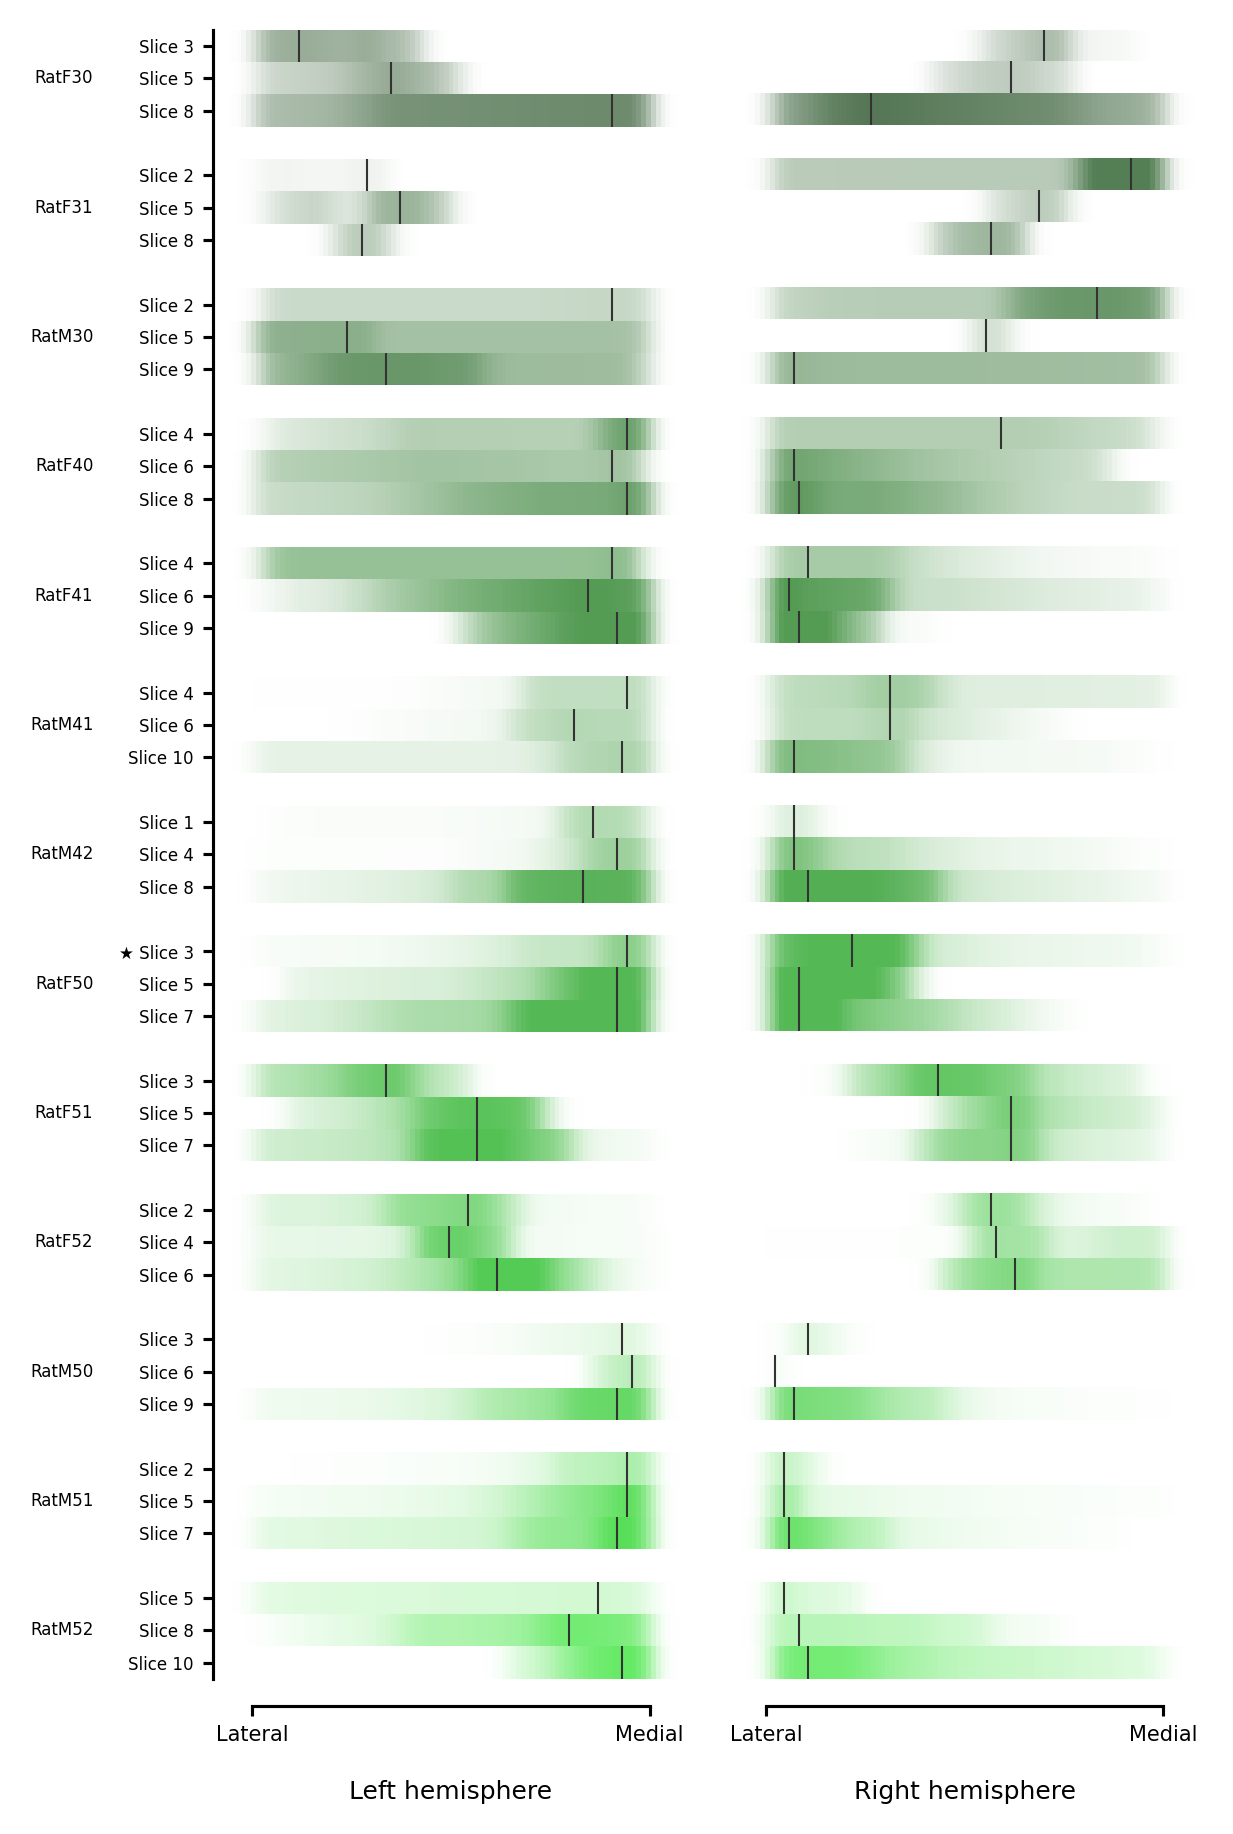

In [9]:

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(4, 6))
plot_extent_lesion_all_rats(lesions_by_side, slice_names, ax_left, ax_right)


RatF30: 0.46, 0.47, 0.47
RatF31: 0.31, 0.28, 0.29
RatM30: 0.49, 0.51, 0.50
RatF40: 0.93, 0.75, 0.84
RatF41: 0.89, 0.92, 0.90
RatM41: 0.89, 0.77, 0.83
RatM42: 0.87, 0.92, 0.89
RatF50: 0.93, 0.87, 0.90
RatF51: 0.49, 0.45, 0.47
RatF52: 0.55, 0.41, 0.48
RatM50: 0.93, 0.93, 0.93
RatM51: 0.93, 0.95, 0.94
RatM52: 0.87, 0.92, 0.89
{'RatF30': 0.46565656565656566, 'RatF31': 0.2939393939393938, 'RatM30': 0.504040404040404, 'RatF40': 0.8414141414141417, 'RatF41': 0.9040404040404044, 'RatM41': 0.8313131313131317, 'RatM42': 0.8939393939393943, 'RatF50': 0.9000000000000004, 'RatF51': 0.4676767676767676, 'RatF52': 0.4797979797979798, 'RatM50': 0.9343434343434347, 'RatM51': 0.9424242424242428, 'RatM52': 0.8939393939393943}


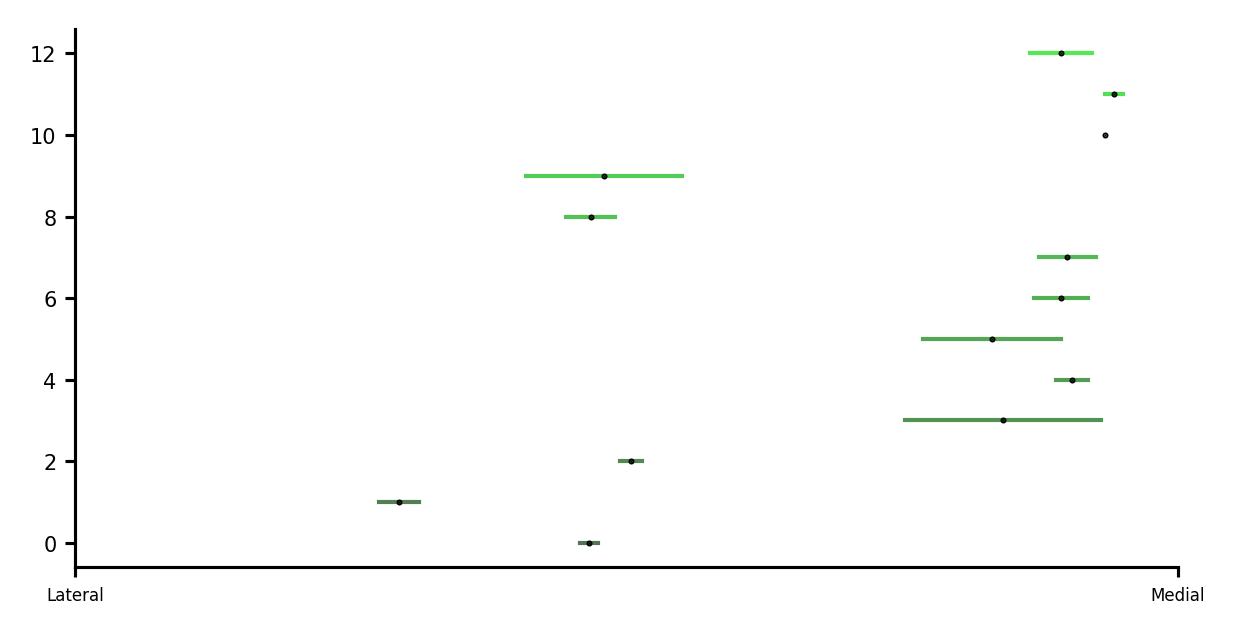

In [10]:
# left_centroids, right_centroids

fig, ax = plt.subplots(1, 1, figsize=(4, 2))

norm_centroid = {animal: 0 for animal in lesioned_rats}

for i, animal in enumerate(lesioned_rats):
    avg_left = np.mean([left_centroids[animal][_]['x'] for _ in range(0, 3)])
    avg_right = 1 - np.mean([right_centroids[animal][_]['x'] for _ in range(0, 3)])

    ax.plot([avg_left, avg_right], [i, i], color=rat_markers[animal][0])

    middle = (avg_left + avg_right) / 2
    ax.scatter(middle, i, color='k', s=.2, marker='o', zorder=10)
    
    norm_centroid[animal] = middle
    print(f"{animal}: {avg_left:.2f}, {avg_right:.2f}, {middle:.2f}")

ax.set_xlim(0, 1)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Lateral', 'Medial'], fontsize=4)

print(norm_centroid)
pickle.dump(norm_centroid, open('picklejar/norm_centroid.p', 'wb'))

# Correlations

Observed Slope: -4.5881
P-value: 0.1203


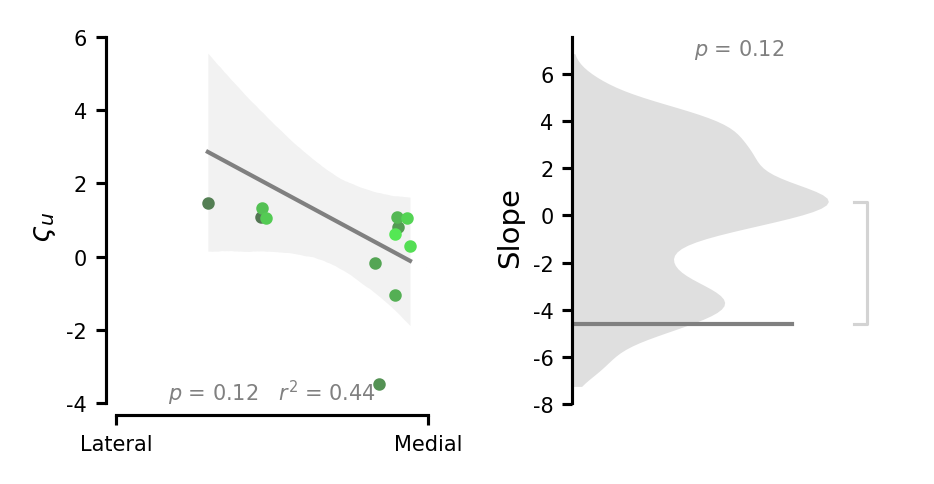

In [11]:
from scipy.optimize import curve_fit

def plot_correlation(var, yname, ax=None, num_iterations=10000):
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(2, 2))

    x, y = [], []
    for animal in lesioned_rats:
        ax.scatter(norm_centroid[animal], var[animal], color=rat_markers[animal][0], zorder=10, s=4, marker=rat_markers[animal][1])
        x.append(norm_centroid[animal])
        y.append(var[animal])

    # fit with np.polyfit
    f = lambda x, *p: np.polyval(p, x)
    p, cov = curve_fit(f, x, y, [1, 1])

    # calculate confidence intervals for fitted line
    xi = np.linspace(np.min(x), np.max(x), 100)
    ps = np.random.multivariate_normal(p, cov, num_iterations)
    ysample = np.asarray([f(xi, *pi) for pi in ps])
    lower = np.percentile(ysample, 2.5, axis=0)
    upper = np.percentile(ysample, 97.5, axis=0)

    # plot the regression and confidence intervals
    y_fit = np.poly1d(p)(xi)
    ax.plot(xi, y_fit, color='gray', zorder=1)
    ax.fill_between(xi, lower, upper, color='gray', alpha=.1, zorder=0, lw=0)


    # shuffle to get p-value
    observed_slope = p[0]
    num_iterations = num_iterations
    shuffled_slopes = []

    for _ in range(num_iterations):
        shuffled_y = np.random.permutation(y)
        p_shuffled, _ = curve_fit(f, x, shuffled_y, [1, 1])
        shuffled_slope = p_shuffled[0]
        shuffled_slopes.append(shuffled_slope)

    # Calculate the p-value
    p_value = (np.abs(shuffled_slopes) >= np.abs(observed_slope)).mean()

    # compute r
    y_mean = np.mean(y)
    y_pred = f(x, *p)
    ss_total = np.sum((y - y_mean) ** 2)
    ss_res = np.sum((y - y_pred) ** 2)
    r_squared = 1 - (ss_res / ss_total)
    r = np.sqrt(r_squared)

    # pvalue annotation
    color = 'k' if p_value < 0.05 else 'gray'
    # ax.annotate(f"$p$ = {p_value:.3f}", xy=(.6, .18), xycoords='axes fraction', fontsize=5, ha='left', va='top', color=color)
    # ax.annotate(f"$r$ = {r:.3f}", xy=(.6, .1), xycoords='axes fraction', fontsize=5, ha='left', va='top', color=color)
    ax.annotate(f'{stars(p_value)}   $r^2$ = {r:.2f}', xy=(.50, .1), color=color, xycoords='axes fraction', fontsize=5, ha='center', va='top')
        



    ax.set_xlim(0, 1)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Lateral', 'Medial'])
    ax.set_ylabel(labels[yname])
    ax.set_ylim(lims[yname][0], lims[yname][-1])
    ax.set_yticks(lims[yname])
    space_axes(ax)
    
    print(f"Observed Slope: {observed_slope:.4f}")
    print(f"P-value: {p_value:.4f}")

    return shuffled_slopes, observed_slope, p_value


fig, axs = plt.subplots(1, 2, figsize=(3, 1.5))
shuffled_slopes, observed_slope, pval = plot_correlation(effort_sensitivity_u, 'effort_sensitivity_u', ax=axs[0])
plot_shuffling(shuffles=shuffled_slopes, observed=observed_slope, pval=pval, yticks=None, ax=axs[1], ylabel='Slope')

Observed Slope: 14.6373
P-value: 0.3786
Observed Slope: 3.8268
P-value: 0.3620
Observed Slope: -4.5881
P-value: 0.1236
Observed Slope: -0.0796
P-value: 0.7833
Observed Slope: 0.0552
P-value: 0.8932
Observed Slope: -0.0124
P-value: 0.8253
Observed Slope: -0.2313
P-value: 0.0313
Observed Slope: 0.2983
P-value: 0.1946
Observed Slope: -0.0041
P-value: 0.9071
Observed Slope: -0.0869
P-value: 0.1351
Observed Slope: 0.1556
P-value: 0.3999
Observed Slope: 0.0272
P-value: 0.3747
Observed Slope: -0.0244
P-value: 0.5517
Observed Slope: 0.0186
P-value: 0.6238
Observed Slope: 0.0014
P-value: 0.8463
Observed Slope: -0.0035
P-value: 0.7638


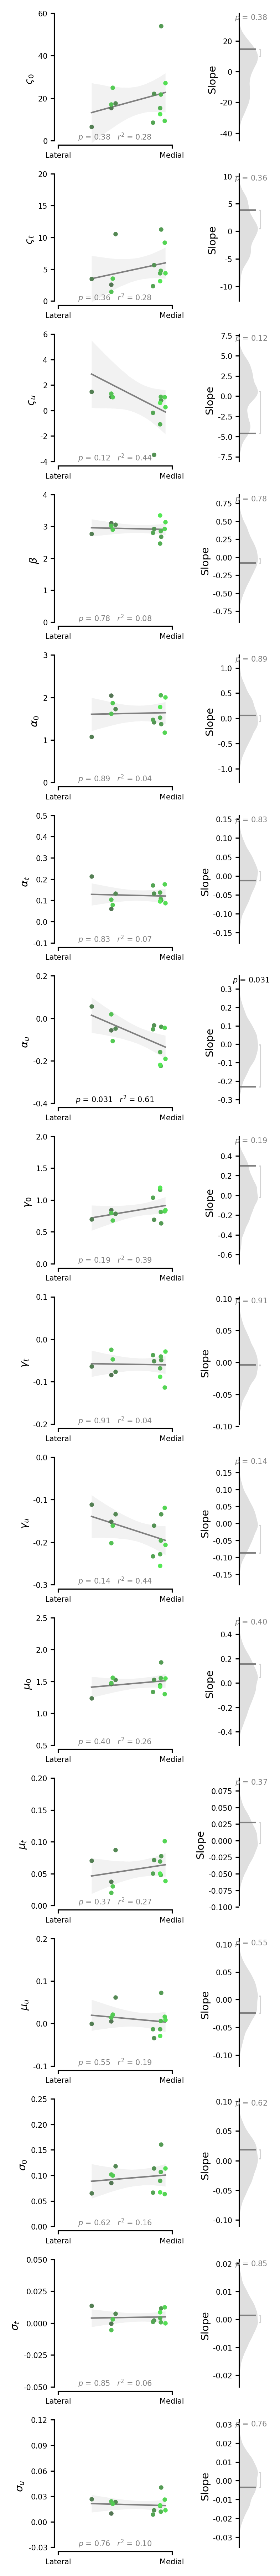

In [12]:

fig, axs = plt.subplots(len(vars), 2, figsize=(2.5, 1.5*len(vars)), gridspec_kw={'width_ratios': [1, 0.2]}, dpi=300)
for i, (var, name) in enumerate(zip(vars, names)):
    shuffled_slopes, observed_slope, pval = plot_correlation(var, name, ax=axs[i][0])
    plot_shuffling(shuffles=shuffled_slopes, observed=observed_slope, pval=pval, yticks=None, ax=axs[i][1], ylabel='Slope')

# Figure SXX

/home/thomas/Desktop/HISTOLOGY/RatF50/slice3.czi


/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:126: RuntimeWarning: invalid value encountered in double_scalars
/home/thomas/Documents/RunningFastAndSlow/.venv/lib/python3.7/site-packages/ipykernel_launcher.py:127: RuntimeWarning: invalid value encountered in double_scalars


Observed Slope: -0.2313
P-value: 0.0303
Observed Slope: -0.0869
P-value: 0.1354
Observed Slope: -4.5881
P-value: 0.1163
Panel A: (0.00588010000000011, 0.9894158200000001)
Panel C: (0.7690673928849903, 0.9894158199999993)


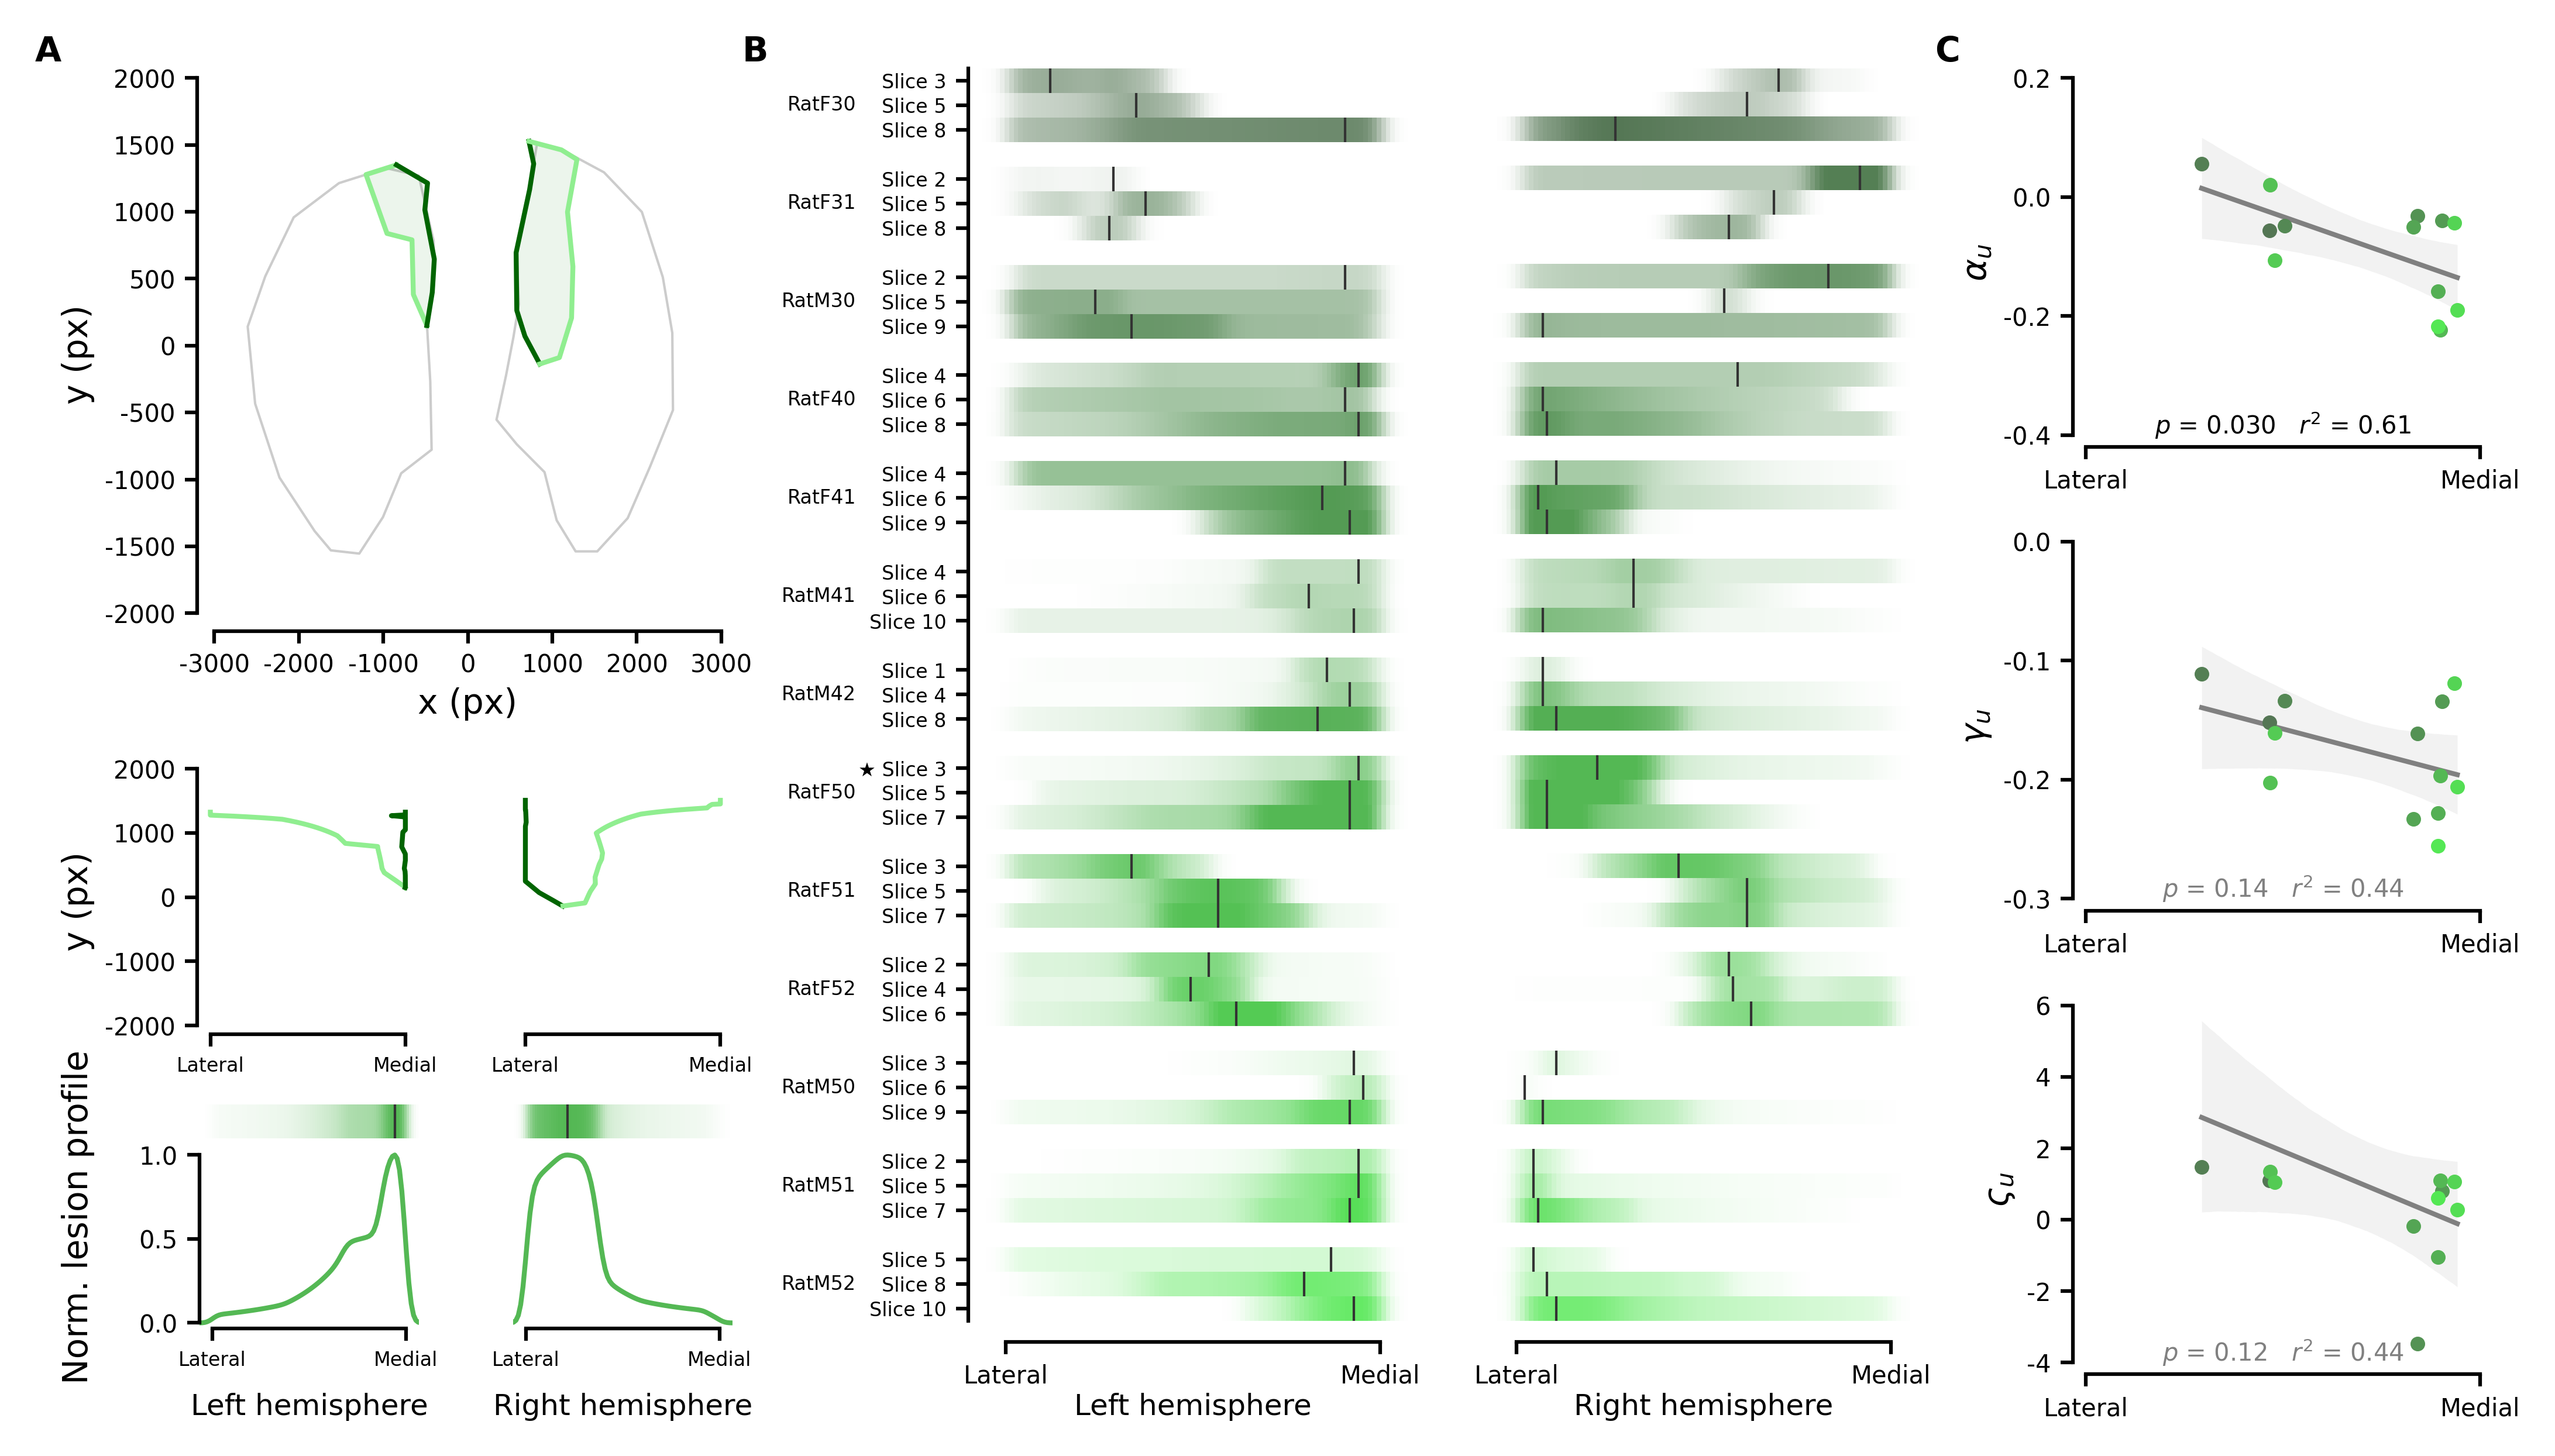

In [19]:
fig=plt.figure(figsize=(cm2inch(18), cm2inch(10)), 
               constrained_layout=True, facecolor='w', dpi=600)

gs = fig.add_gridspec(1, 3, width_ratios=[1.1, 1.8, 0.9], wspace=1)

left = gs[0].subgridspec(3, 1, height_ratios=[1, 0.5, 0.5])
ax_anat = fig.add_subplot(left[0])
middle_row = left[1].subgridspec(1, 2, width_ratios=[1, 1])
ax_profile_L = fig.add_subplot(middle_row[0, 0])
ax_profile_R = fig.add_subplot(middle_row[0, 1], sharey=ax_profile_L)

bottom_row = left[2].subgridspec(1, 2, width_ratios=[1, 1])
ax_lesion_bar_L = fig.add_subplot(bottom_row[0, 0], sharex=ax_profile_L)
ax_lesion_bar_R = fig.add_subplot(bottom_row[0, 1], sharey=ax_lesion_bar_L, sharex=ax_profile_R)


middle_col = gs[1].subgridspec(1, 2, width_ratios=[1, 1])
ax_extent_left = plt.subplot(middle_col[0])
ax_extent_right = plt.subplot(middle_col[1])

right = gs[2].subgridspec(3, 1, height_ratios=[1, 1, 1])
alpha_u_corr = plt.subplot(right[0])
gamma_u_corr = plt.subplot(right[1])
varepsilon_u_corr = plt.subplot(right[2])



explanation_plot(ax_anat, ax_profile_L, ax_profile_R, ax_lesion_bar_L, ax_lesion_bar_R)

plot_extent_lesion_all_rats(lesions_by_side, slice_names, ax_extent_left, ax_extent_right)

plot_correlation(alpha_u, 'alpha_u', ax=alpha_u_corr)
plot_correlation(gamma_u, 'gamma_u', ax=gamma_u_corr)
plot_correlation(effort_sensitivity_u, 'effort_sensitivity_u', ax=varepsilon_u_corr)


add_all_letters([ax_anat, alpha_u_corr], ["A", "C"], verbose=True)
add_one_letter(ax_extent_left, "B", x=0.29, y=.9894)

plt.savefig("./Figures_paper/Figure_SXX.pdf", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="pdf", dpi=600)

plt.savefig("./Figures_paper/Figure_SXX.svg", facecolor='w', 
                edgecolor='none', bbox_inches='tight', format="svg", dpi=600)